   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.35 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, 

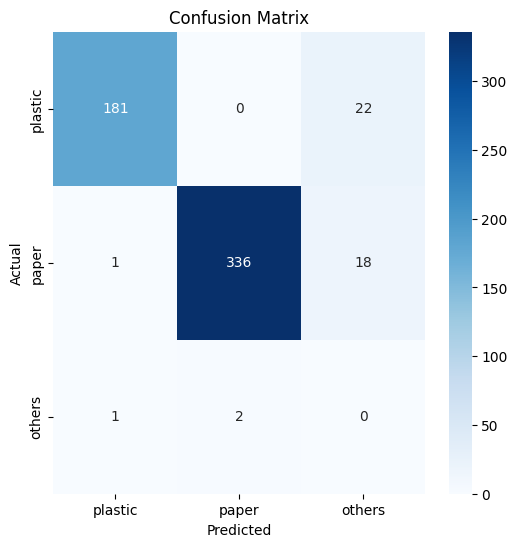

              precision    recall  f1-score   support

     plastic       0.99      0.89      0.94       203
       paper       0.99      0.95      0.97       355
      others       0.00      0.00      0.00         3

    accuracy                           0.92       561
   macro avg       0.66      0.61      0.64       561
weighted avg       0.99      0.92      0.95       561



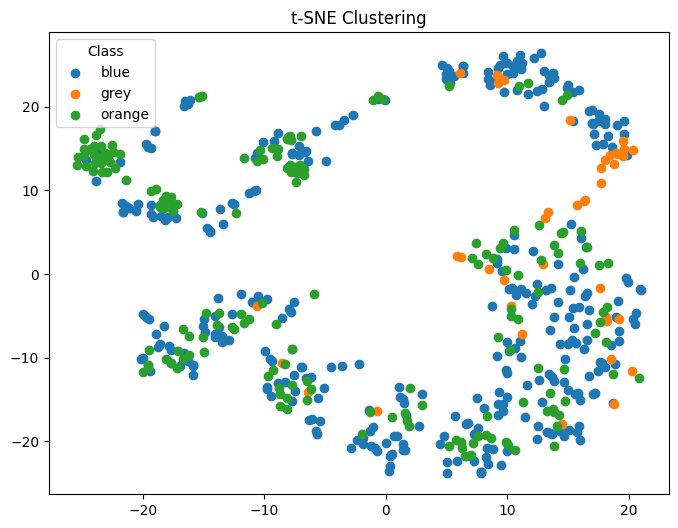

✅ Smart model ready (plastic/paper + others logic)


In [1]:
# Install dependencies
!pip install ultralytics albumentations scikit-learn seaborn --quiet

import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
import albumentations as A

# -----------------------
# Paths
# -----------------------
DATASET_PATH = "/kaggle/input/datasets/afsanamimiiiii/paper-plastic"
WORKING_PATH = "/kaggle/working/dataset"

shutil.copytree(DATASET_PATH, WORKING_PATH, dirs_exist_ok=True)

# -----------------------
# Augmentation
# -----------------------
aug = A.Compose([
    A.MotionBlur(p=0.3),
    A.GaussianBlur(p=0.3),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2)
])

train_images = glob(os.path.join(WORKING_PATH, "train/images/*.jpg"))
for path in train_images:
    image = cv2.imread(path)
    augmented = aug(image=image)
    aug_img = augmented['image']

    new_img_path = path.replace(".jpg", "_aug.jpg")
    cv2.imwrite(new_img_path, aug_img)

    label_path = path.replace("images", "labels").replace(".jpg", ".txt")
    new_label_path = label_path.replace(".txt", "_aug.txt")
    if os.path.exists(label_path):
        shutil.copy(label_path, new_label_path)

# -----------------------
# data.yaml (ONLY 2 classes)
# -----------------------
data_yaml = f"""
path: {WORKING_PATH}
train: train/images
val: valid/images
test: test/images

names:
  0: plastic
  1: paper
"""
with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(data_yaml)

# -----------------------
# Load model
# -----------------------
model = YOLO('yolov8n.pt')

# -----------------------
# Train
# -----------------------
model.train(
    data='/kaggle/working/data.yaml',
    epochs=100,
    imgsz=720,
    batch=16,
    patience=25,
    optimizer='AdamW',
    lr0=0.001,
    weight_decay=0.0005,
    augment=True
)

# -----------------------
# Validation
# -----------------------
metrics = model.val()
print("mAP50-95:", metrics.box.map)

# -----------------------
# SMART CONFIDENCE THRESHOLD
# -----------------------
LOW_TH = 0.6  # Best balance for you

# -----------------------
# Classification Evaluation
# -----------------------
y_true = []
y_pred = []

test_images = glob(WORKING_PATH + "/test/images/*.jpg")

for img_path in test_images:

    # -------- TRUE LABEL --------
    label_path = img_path.replace("images","labels").replace(".jpg",".txt")

    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = f.readlines()
            if len(lines) > 0:
                cls_val = int(lines[0].split()[0])
            else:
                cls_val = 2   # no object → others
    else:
        cls_val = 2

    y_true.append(cls_val)

    # -------- PREDICTION --------
    pred = model.predict(img_path, conf=0.01, verbose=False)[0]

    if pred.boxes is not None and len(pred.boxes) > 0:
        confs = pred.boxes.conf.cpu().numpy()
        cls_ids = pred.boxes.cls.cpu().numpy()

        best_idx = np.argmax(confs)
        best_conf = confs[best_idx]
        best_cls = int(cls_ids[best_idx])

        # 🔥 SMART DECISION
        if best_conf >= LOW_TH:
            pred_class = best_cls        # plastic/paper
        else:
            pred_class = 2               # others
    else:
        pred_class = 2  # no detection

    y_pred.append(pred_class)

# -----------------------
# Confusion Matrix
# -----------------------
labels = [0,1,2]
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['plastic','paper','others'],
            yticklabels=['plastic','paper','others'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -----------------------
# Classification Report
# -----------------------
print(classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=['plastic','paper','others'],
    zero_division=0
))

# -----------------------
# t-SNE Clustering
# -----------------------
features = []
colors = []

for img_path in test_images:
    pred = model.predict(img_path, conf=0.01, verbose=False)[0]

    if pred.boxes is not None and len(pred.boxes) > 0:
        xywh = pred.boxes.xywh.cpu().numpy().flatten()
        conf = pred.boxes.conf.cpu().numpy()[0]

        if conf < LOW_TH:
            colors.append('grey')
        else:
            cls_id = int(pred.boxes.cls.cpu().numpy()[0])
            colors.append('orange' if cls_id==0 else 'blue')

        features.append(xywh)
    else:
        features.append(np.zeros(4))
        colors.append('grey')

# Padding
max_len = max(len(f) for f in features)
padded = np.array([np.pad(f,(0,max_len-len(f))) for f in features])

tsne = TSNE(n_components=2, random_state=42)
res = tsne.fit_transform(padded)

plt.figure(figsize=(8,6))
for c in np.unique(colors):
    idx = [i for i,x in enumerate(colors) if x==c]
    plt.scatter(res[idx,0], res[idx,1], label=c)

plt.legend(title="Class")
plt.title("t-SNE Clustering")
plt.show()

# -----------------------
# Done
# -----------------------
print("✅ Smart model ready (plastic/paper + others logic)")
